# Análise Exploratória de Dados e Preparação
Este notebook realiza a Análise Exploratória de Dados (EDA) do dataset de preços de imóveis, respondendo às exigências detalhadas no projeto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Configurações de estilo
sns.set_theme(style="whitegrid")
os.makedirs('../reports', exist_ok=True)

# Carregar os dados
df = pd.read_csv('../data/treino.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 1. Análise de Valores Nulos e Dependências
Aqui identificamos colunas com valores nulos. Distinguimos nulos estruturais (onde "NA" apenas indica a ausência de um item, como piscina) de nulos de fato.

In [2]:
# Porcentagem de nulos por coluna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_pct = (nulos / len(df)) * 100

df_nulos = pd.DataFrame({'Total Nulos': nulos, 'Porcentagem (%)': nulos_pct})
display(df_nulos)

# Análise de dependência de nulos na garagem
# A nulidade em GarageYrBlt, GarageFinish, GarageQual e GarageCond ocorre simultaneamente quando GarageType é nulo?
garage_cols = ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
print("Nulos cruzados nas variáveis de Garagem:")
df[garage_cols].isnull().sum()

,Total Nulos,Porcentagem (%)
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


Nulos cruzados nas variáveis de Garagem:


GarageType      64
GarageYrBlt     64
GarageFinish    64
GarageQual      64
GarageCond      64
dtype: int64

**Conclusões dos Nulos:**
- Variáveis como `PoolQC`, `MiscFeature`, `Alley`, e `Fence` possuem muitos nulos, o que indica ausência dessas estruturas.
- Observa-se a dependência estrutural: Sempre que `GarageType` é nulo (sem garagem), as outras variáveis de garagem também são nulas. O mesmo ocorre com os recursos de Porão (`BsmtQual`, `BsmtCond`, etc.).
- Variáveis numéricas como `LotFrontage` e `MasVnrArea` possuem nulos reais, os quais podemos simular/imputar por **0** ou pela **Mediana**.

## 2. Estatísticas Descritivas Limites
Verificamos agora a descrição básica (contagem, média, desvio padrão, mínimo, máximo e quartis) das variáveis numéricas do nosso dataset.

In [3]:
# Resumo estatístico apenas das colunas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1168.0,730.904966,425.369088,1.0,360.75,732.5,1101.75,1460.0
MSSubClass,1168.0,56.849315,42.531862,20.0,20.00,50.0,70.00,190.0
LotFrontage,951.0,70.343849,24.897021,21.0,59.00,70.0,80.00,313.0
LotArea,1168.0,10689.642123,10759.366198,1300.0,7587.25,9600.0,11700.00,215245.0
OverallQual,1168.0,6.121575,1.367619,1.0,5.00,6.0,7.00,10.0
OverallCond,1168.0,5.584760,1.116062,1.0,5.00,5.0,6.00,9.0
YearBuilt,1168.0,1970.965753,30.675495,1872.0,1953.00,1972.0,2001.00,2010.0
YearRemodAdd,1168.0,1984.897260,20.733955,1950.0,1966.00,1994.0,2004.00,2010.0
MasVnrArea,1162.0,103.771945,173.032238,0.0,0.00,0.0,166.00,1378.0
BsmtFinSF1,1168.0,446.023973,459.070977,0.0,0.00,384.5,721.00,5644.0


## 3. Matriz de Correlação Global
As correlações nos ajudam a entender como as variáveis numéricas se relacionam com o nosso target (`SalePrice`), além de permitir identificar relações fortes entre variáveis independentes.

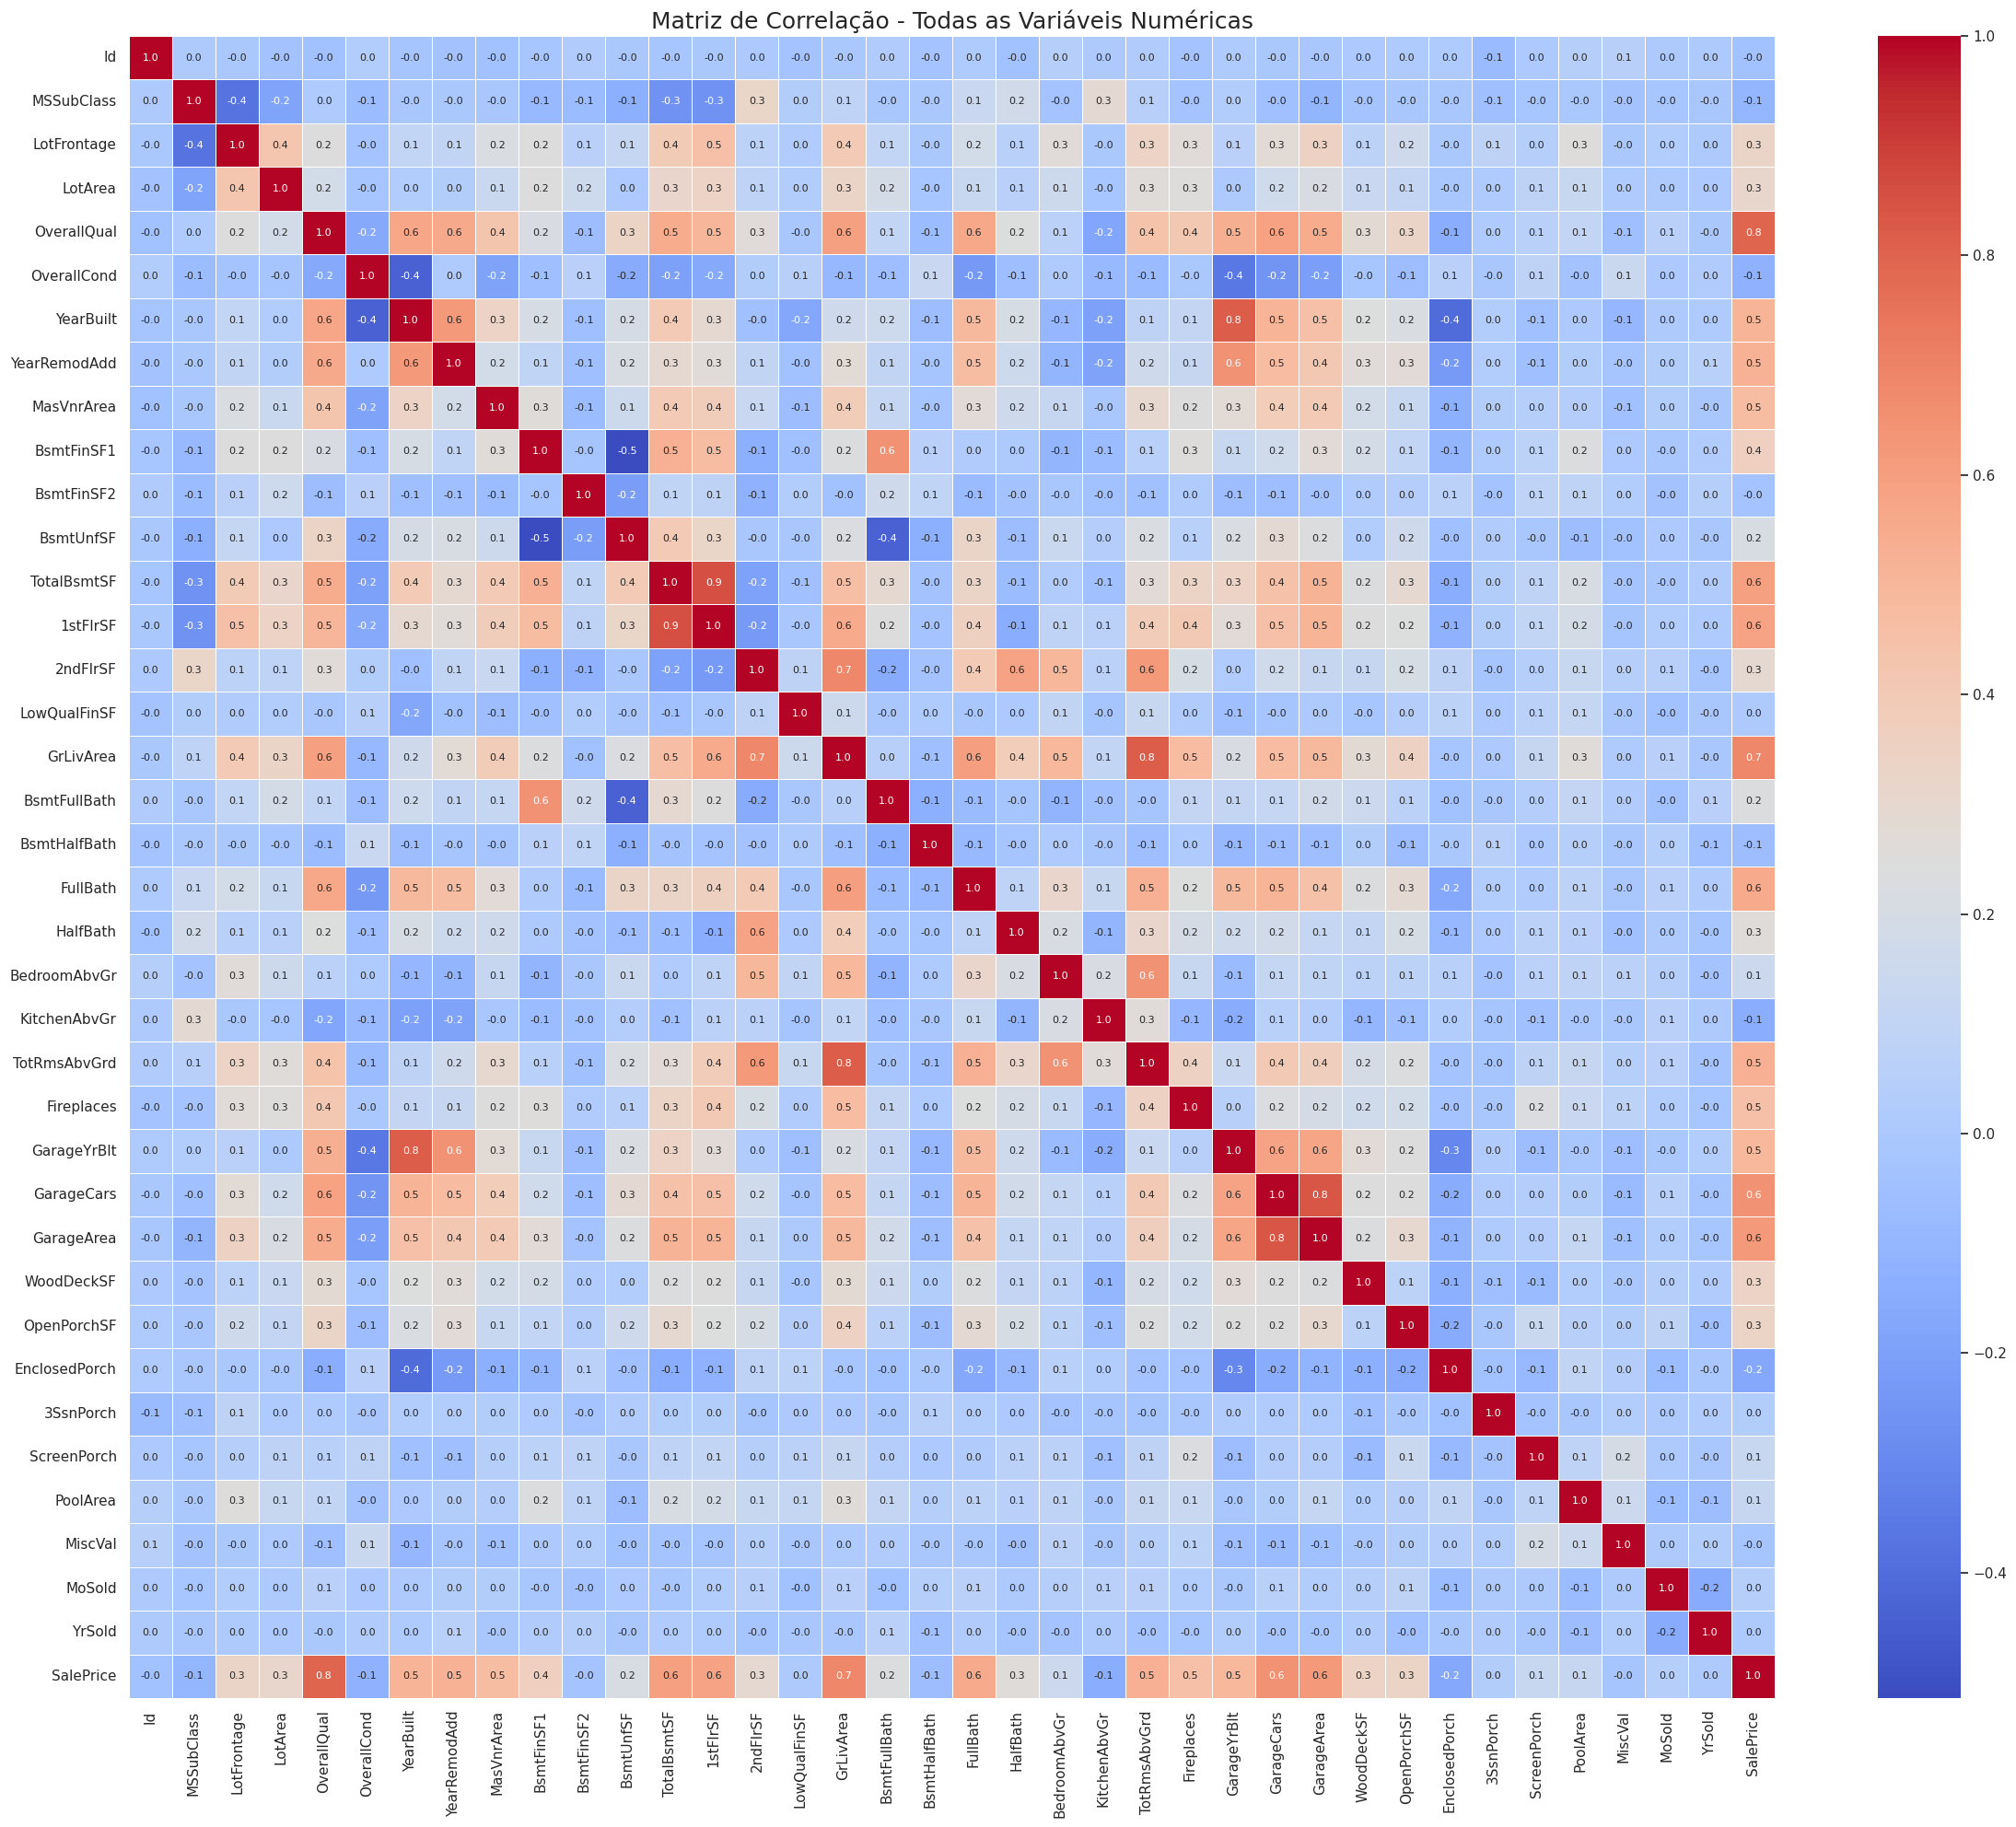

In [4]:
# Selecionar variáveis numéricas
num_cols = df.select_dtypes(include=["number"]).columns
df_num = df[num_cols].dropna()

# Calcular correlação
corr_matrix = df_num.corr()

# Exibir o heatmap de todas as variáveis numéricas para análise completa
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".1f", linewidths=.5, annot_kws={"size": 8})
plt.title("Matriz de Correlação - Todas as Variáveis Numéricas", fontsize=18)
plt.tight_layout()
plt.savefig("../reports/heatmap_correlacao.png")
plt.show()

## 4. Identificação de Colinearidade e Redução de Dimensionalidade
A multicolinearidade ocorre quando duas ou mais variáveis previsoras estão altamente correlacionadas, fornecendo informação redundante para o modelo.

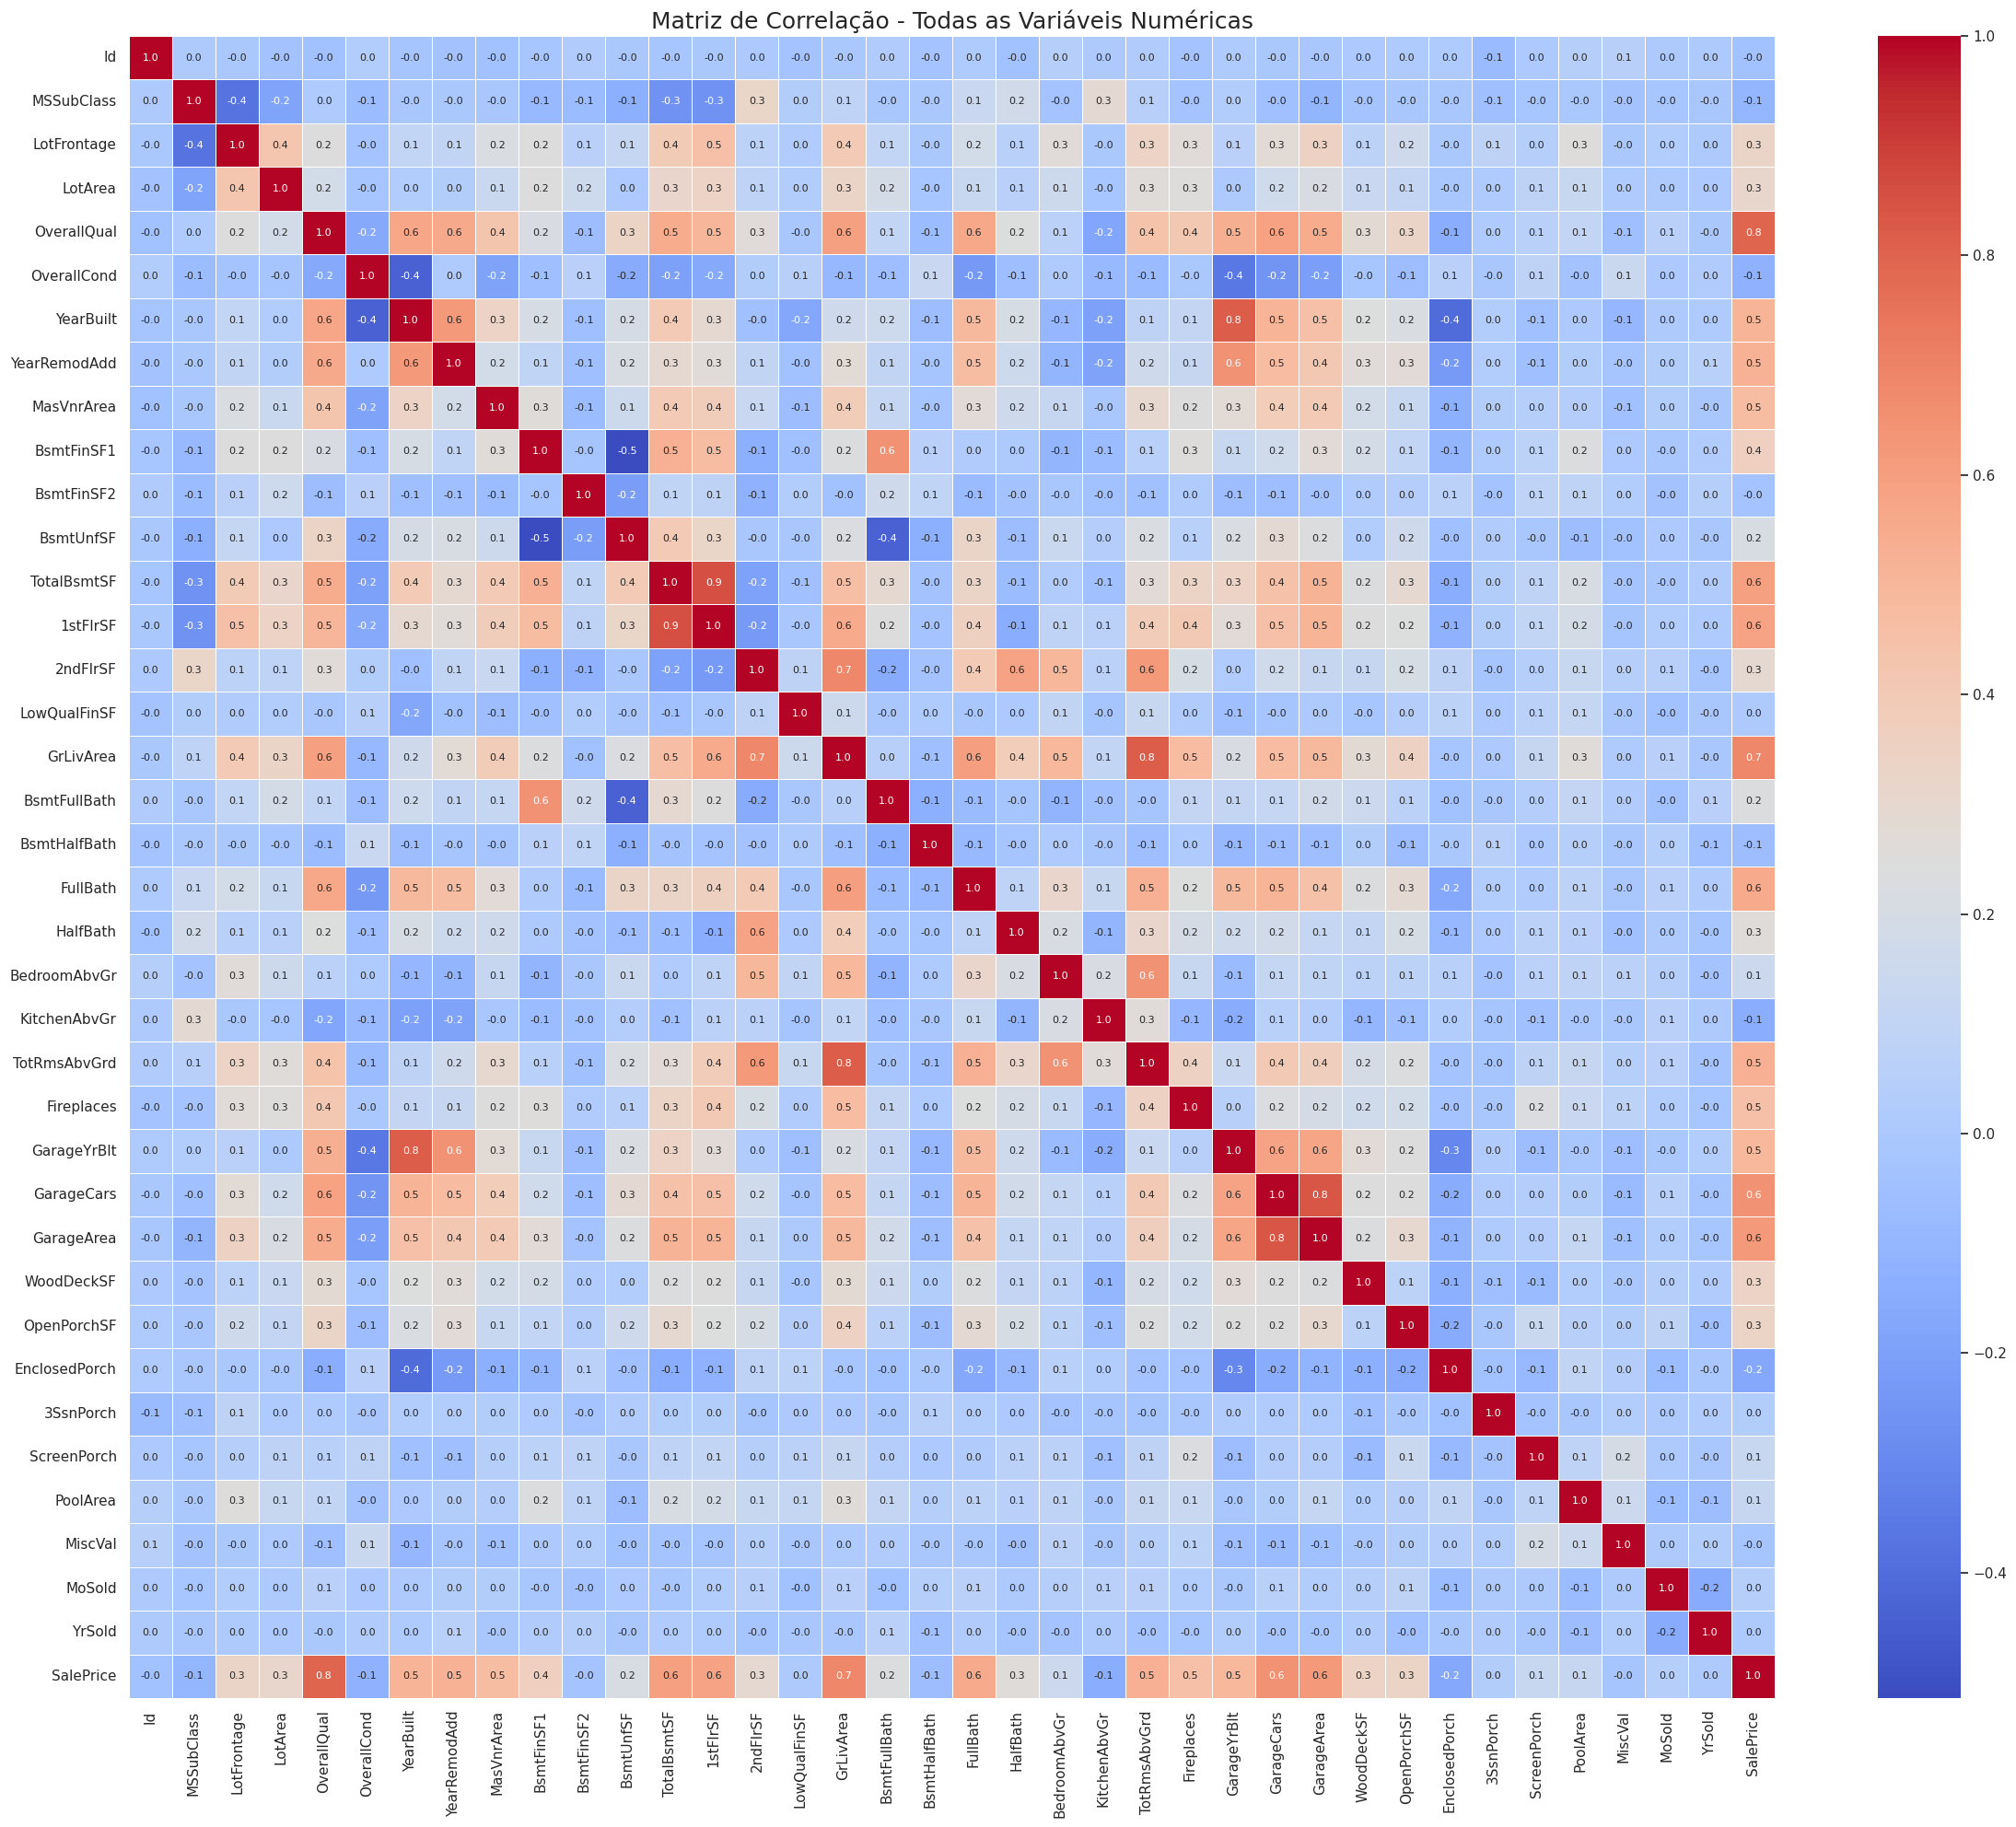

In [5]:
# Selecionar variáveis numéricas
num_cols = df.select_dtypes(include=["number"]).columns
df_num = df[num_cols].dropna()

# Calcular correlação
corr_matrix = df_num.corr()

# Exibir o heatmap de todas as variáveis numéricas para análise completa
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".1f", linewidths=.5, annot_kws={"size": 8})
plt.title("Matriz de Correlação - Todas as Variáveis Numéricas", fontsize=18)
plt.tight_layout()
plt.savefig("../reports/heatmap_correlacao.png")
plt.show()

## 5. Técnicas de Padronização e Ajuste
A variável alvo `SalePrice` muitas vezes não segue uma distribuição normal e apresenta assimetria à direita. Vamos aplicar o logaritmo $\log(1+x)$ para torná-la normal, e demonstrar `StandardScaler`.

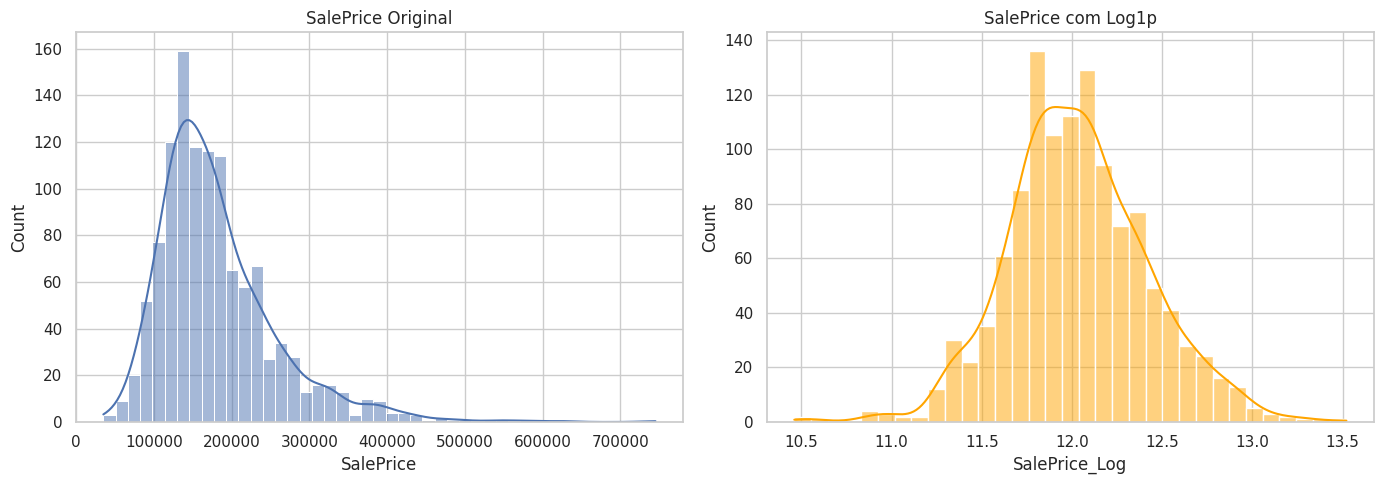

Média escalonada: -1.307933974215938e-16
Desvio padrão escalonado: 1.000428357269592


,Street_Pave,CentralAir_Y
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=ax[0])
ax[0].set_title('SalePrice Original')

# Aplicar transformação logarítmica
df['SalePrice_Log'] = np.log1p(df['SalePrice'])
sns.histplot(df['SalePrice_Log'], kde=True, ax=ax[1], color='orange')
ax[1].set_title('SalePrice com Log1p')

plt.tight_layout()
plt.savefig('../reports/saleprice_dist.png')
plt.show()

# Exemplo de Padronização com StandardScaler
scaler = StandardScaler()
df['GrLivArea_Scaled'] = scaler.fit_transform(df[['GrLivArea']])
print("Média escalonada:", df['GrLivArea_Scaled'].mean())
print("Desvio padrão escalonado:", df['GrLivArea_Scaled'].std())

# Exemplo de One-Hot Encoding em colunas categóricas simples
df_encoded = pd.get_dummies(df[['Street', 'CentralAir']], drop_first=True)
display(df_encoded.head())

## 6. Verificação de Outliers
Variáveis importantes podem conter *outliers* graves que distorcem as predições de Modelos Lineares. Vamos olhar a relação entre a principal variável de espaço (`GrLivArea`) e `SalePrice`.

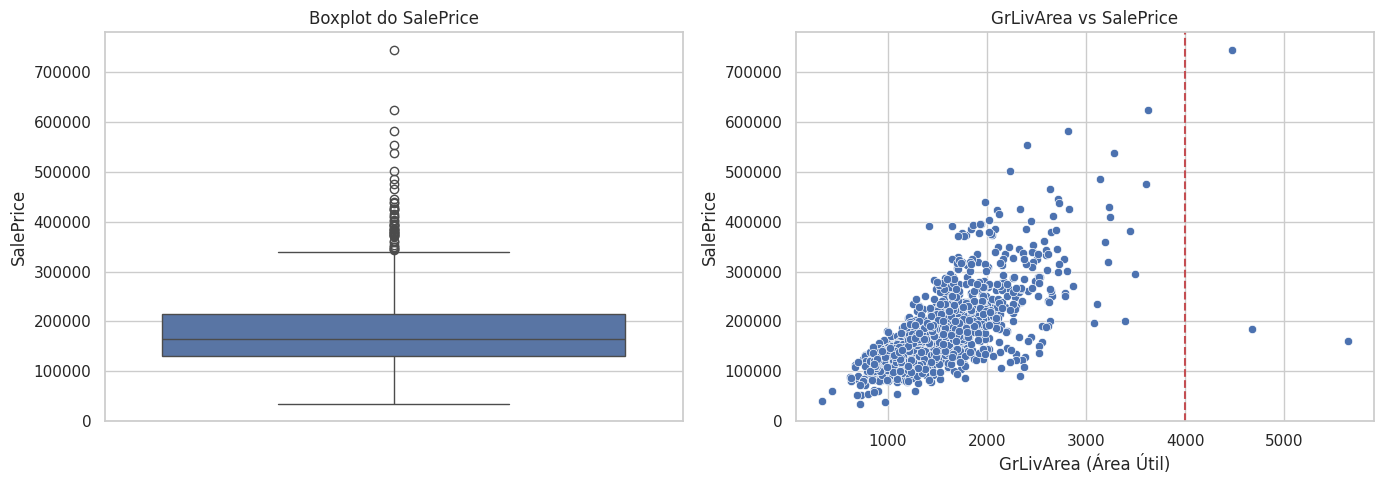

Tratamento: Casas com mais de 4000 sqft e preços muito baixos (abaixo de $300k) geralmente são excluídas no treinamento.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['SalePrice'], ax=ax[0])
ax[0].set_title('Boxplot do SalePrice')

sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], ax=ax[1])
ax[1].set_title('GrLivArea vs SalePrice')
ax[1].set_xlabel('GrLivArea (Área Útil)')
ax[1].set_ylabel('SalePrice')

# Destacando os prováveis outliers apontados na literatura do dataset de Ames (Casas grandes mas baratas)
ax[1].axvline(4000, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('../reports/outliers_saleprice.png')
plt.show()

print("Tratamento: Casas com mais de 4000 sqft e preços muito baixos (abaixo de $300k) geralmente são excluídas no treinamento.")

## 7. Remoção de Colinearidade e Nova Matriz
A partir da matriz global e de nosso limiar (correlação > 0.6), decidimos agrupar/remover as variáveis de forma a mantermos a que nos dá mais informação sobre `SalePrice`.

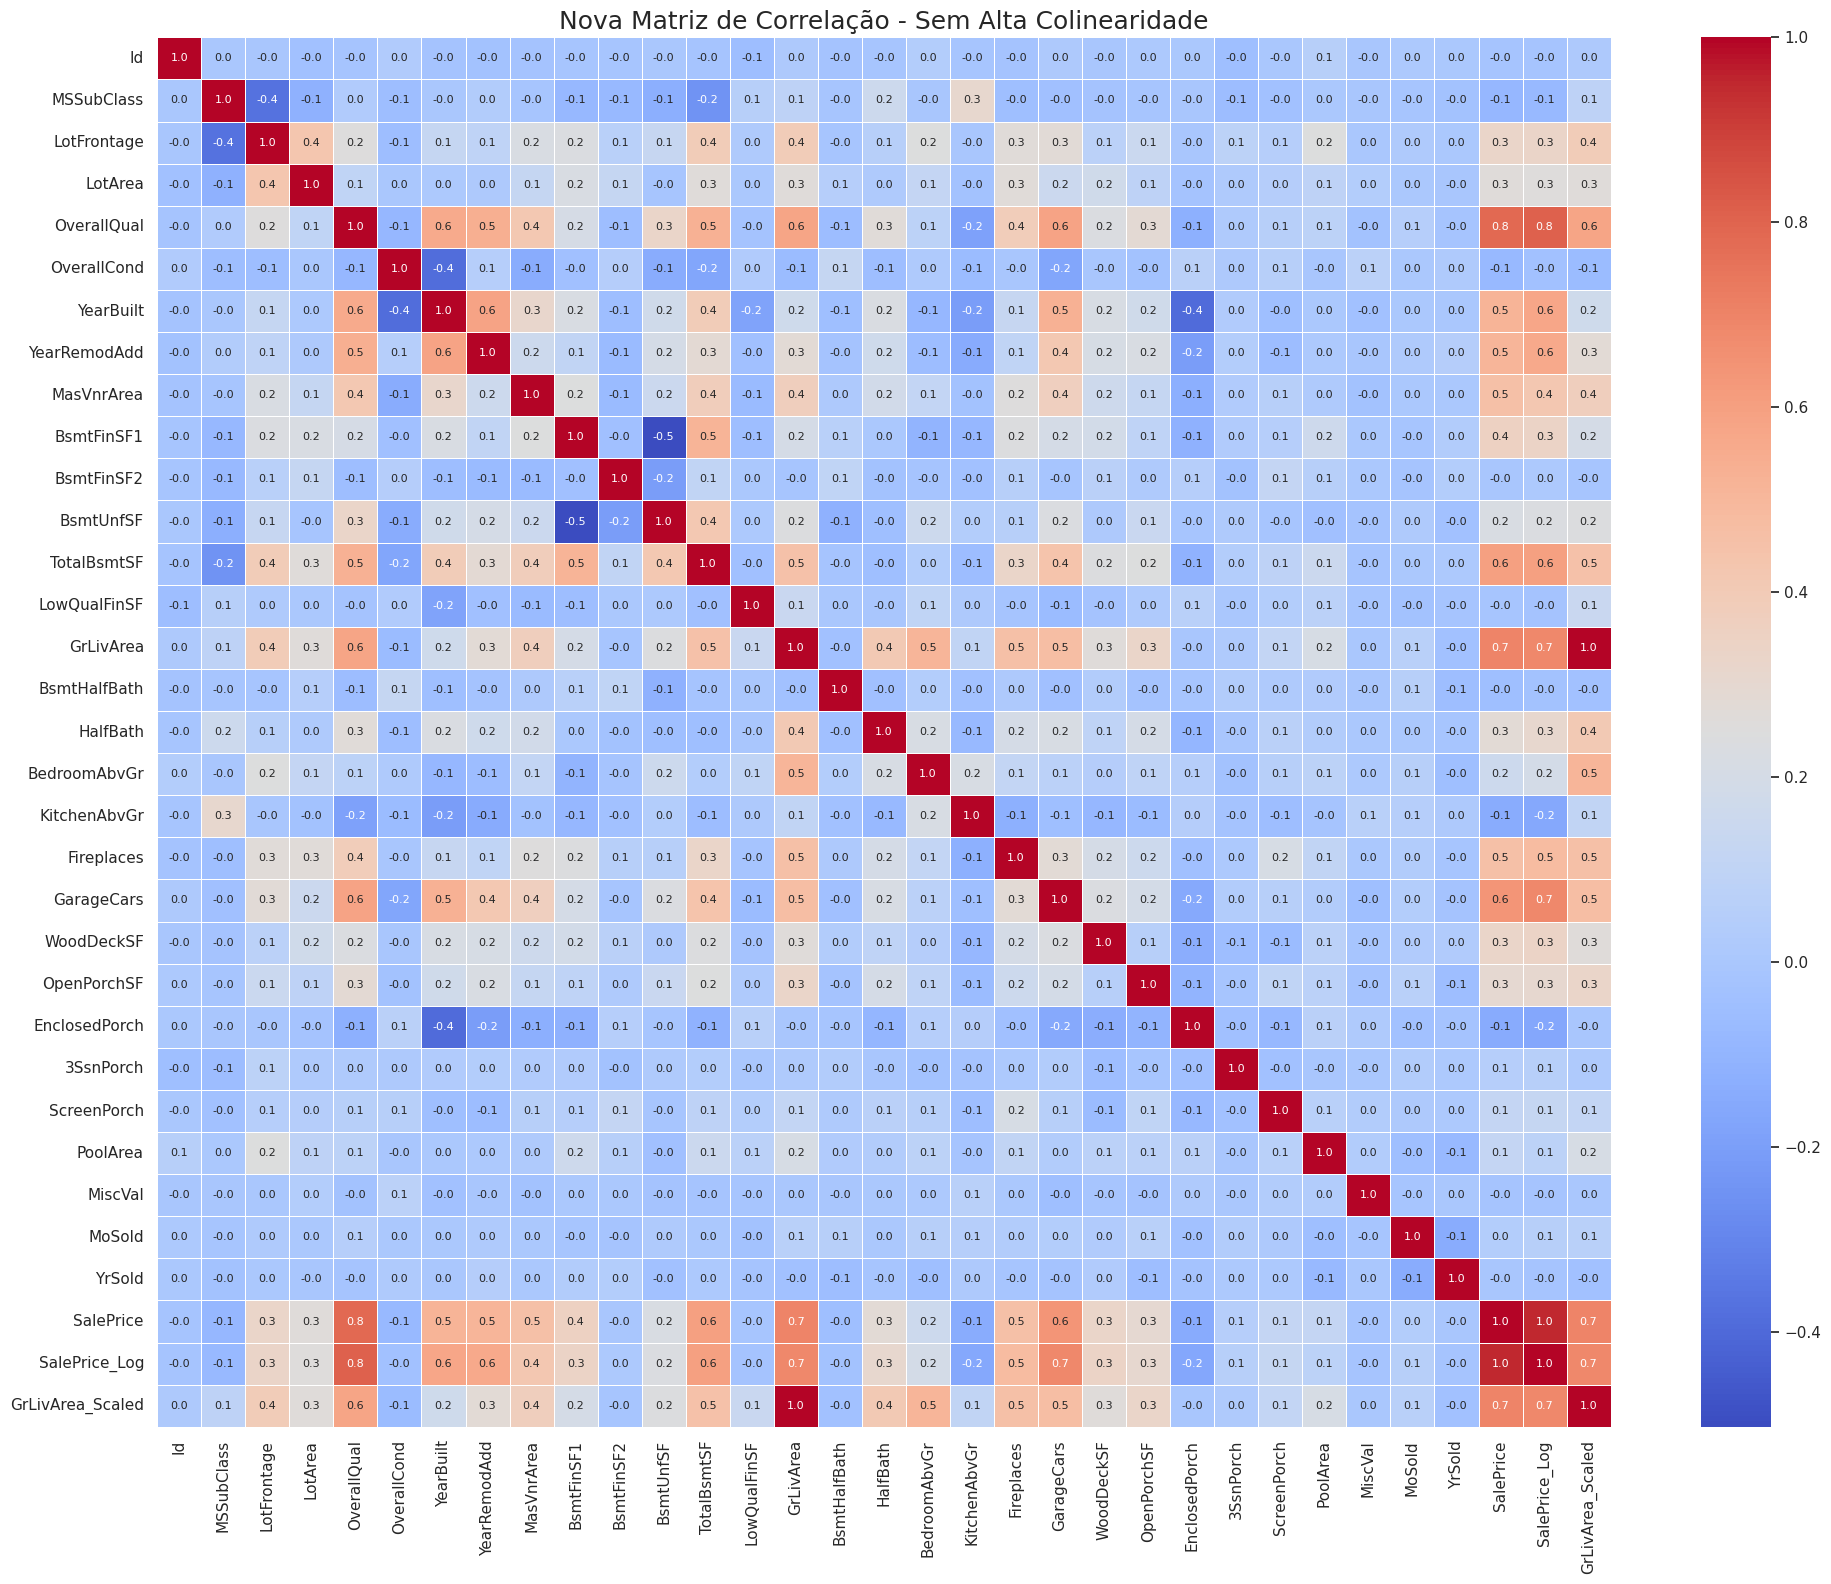

In [8]:
# Remover features altamente correlacionadas
cols_to_drop = ["GarageArea", "1stFlrSF", "TotRmsAbvGrd", "GarageYrBlt", "2ndFlrSF", "BsmtFullBath", "FullBath"]

# Assegurar que elas existem antes de dropar (no caso de rodar a célula várias vezes)
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# Recalcular matriz para ver o novo estado
num_cols_new = df.select_dtypes(include=["number"]).columns
corr_matrix_new = df[num_cols_new].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix_new, annot=True, cmap="coolwarm", fmt=".1f", linewidths=.5, annot_kws={"size": 8})
plt.title("Nova Matriz de Correlação - Sem Alta Colinearidade", fontsize=18)
plt.tight_layout()
plt.savefig("../reports/heatmap_sem_colinearidade.png")
plt.show()

## 8. Tratamento Inteligente de Valores Nulos
Agora vamos preparar os dados faltantes de forma limpa, baseando-se nas regras de estrutura do dataset.

In [9]:
# 1. Nulos Estruturais em Categóricas (Onde NA = Não possui)
structural_nulls = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", 
                    "PoolQC", "Fence", "MiscFeature"]
for col in structural_nulls:
    if col in df.columns:
        df[col] = df[col].fillna("None")

# 2. Nulos Numéricos
num_cols_with_na = [col for col in df.select_dtypes(include=["number"]).columns if df[col].isnull().any()]
for col in num_cols_with_na:
    df[col] = df[col].fillna(0)

# 3. Nulos Reais em Categóricas
cat_cols_with_na = [col for col in df.select_dtypes(exclude=["number"]).columns if df[col].isnull().any()]
for col in cat_cols_with_na:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total de Nulos após imputação:", df.isnull().sum().sum())

Total de Nulos após imputação: 0


## 9. One-Hot Encoding e Exportação
Para que os algoritmos de ML processem nossas variáveis de texto, precisamos convertê-las para binário (dummy variables). Utilizaremos drop_first=True para evitar a *dummy trap*.

In [10]:
# One-hot encoding de todo o dataframe categórico
df_preparado = pd.get_dummies(df, drop_first=True)

# Checagem dos tamanhos
print("Shape original:", df.shape)
print("Shape preparado:", df_preparado.shape)

# Salvar novo CSV
df_preparado.to_csv("../data/treino_preparado.csv", index=False)
print("Dataset final exportado com sucesso para data/treino_preparado.csv")

Shape original: (1168, 76)
Shape preparado: (1168, 253)
Dataset final exportado com sucesso para data/treino_preparado.csv
